# Pipeline reproducible de clasificacion y priorizacion de tickets NOC (FTTH + DAS)

**Proyecto.** Asistente de operacion de red basado en modelos de lenguaje: clasificar y priorizar
tickets de un centro de operacion de red (NOC) por **criticidad** (T1: Critico/Leve) y **tipo de
trabajo** (T2), **al abrir el ticket (t = 0)**. Dataset pseudonimizado de 588 tickets (2023-2026).

**Que hace este cuaderno.** Consolida en un solo documento reproducible las tres etapas del proyecto:
el analisis exploratorio con firewall del target (P1), la particion temporal con embargo (P2), la
escalera de representacion (P3), la validez de la senal (P4), el producto operativo full-semantico
(P5), la calibracion y el drift (P6), y el prototipo de dos capas con su reproducibilidad (P7).

**El hallazgo, en una frase.** Las senales **estructurales** disponibles en t = 0 (distrito, longitud
de la descripcion, banderas de faltante) **no discriminan** la criticidad; pero la **semantica de la
descripcion inicial si la anticipa**, de forma estadisticamente robusta. Leyendo tambien la urgencia
del mismo texto, el ranking captura **todos** los eventos criticos de la prueba (Recall@5 de nivel-3
= 1,0). La unica limitacion es de escala de datos, no de metodo.

**Como esta organizado (visor reproducible).** Es un **visor**: computa en vivo solo lo ligero del EDA
(asociaciones, distribuciones, el split), mientras que los numeros del modelado y la validacion se
**leen de los artefactos JSON canonicos** de `outputs/` (ningun modelo se re-entrena aqui). Para que
lo explicado sea literalmente lo ejecutado, la seccion **Utilidades / codigo** exhibe el codigo real
de cada funcion de soporte con `inspect.getsource`.

> Cada fase cierra con un bloque **«En terminos simples»**, la version llana del resultado, pensada
> para redactar el informe sin perder el detalle tecnico.

## Configuracion unica del cuaderno

Una sola celda de arranque fija el entorno (bloque de importacion estandar del proyecto,
`RANDOM_STATE = 42`), carga los **dos splits** que usa el pipeline y **todos** los artefactos
canonicos. Ninguna fase posterior repite este arranque.

- **Split canonico (60/40 temporal)** sobre el dataset completo: la vara del EDA y del proxy-scan.
- **Split temporal con embargo de 7 dias**: la base del modelado (P2 en adelante); su `test` queda
  con **11 criticos**, el numero que gobierna la potencia de todo lo que sigue.
- **Artefactos JSON** (`outputs/afg3_*.json`): escaleras T1 y T2, producto full-semantico, errores y
  potencia, validacion (permutacion, anti-circularidad, drift, scorer) y benchmark de latencia.

In [1]:
# --- Bloque de importacion estandar del proyecto ---
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('font', **{'size': 12})
import warnings
warnings.filterwarnings('ignore')
import sys, json, inspect
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_style("whitegrid")

RANDOM_STATE = 42

# Raiz del proyecto (robusta al directorio de trabajo)
ROOT = Path.cwd()
while not (ROOT / "scripts" / "_avance_final_common.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

# --- Loaders y helpers canonicos (canon-vivo; NUNCA el namespace legacy) ---
from _avance_final_common import cargar_split_temporal_canonico, cargar_split_temporal_embargo
from afg3_baselines_clasicos import NUM_COLS, CAT_COLS, construir_features, build_preprocessor
from src.eda import cramers_v
from src.eval_producto import compute_prioridad_ordinal, compute_score_combinado

# --- Split CANONICO (60/40) sobre el dataset completo: la vara del EDA ---
_tr, _te = cargar_split_temporal_canonico()
df_full = pd.concat([_tr, _te], ignore_index=True).sort_values("Fecha aviso incidencia").reset_index(drop=True)
df_full = construir_features(df_full)
df_full["anio"] = df_full["Fecha aviso incidencia"].dt.year
df_full["emergencia"] = (df_full["target_t2"] == 2).astype(int)          # T2 == Emergencia
df_full["nivel_ordinal"] = compute_prioridad_ordinal(df_full["target_criticidad"], df_full["target_t2"])
N_TRAIN = int(len(df_full) * 0.60)
TRAIN = df_full.iloc[:N_TRAIN].copy()                                     # vara del proxy-scan (P1)

# --- Split TEMPORAL + EMBARGO (7 dias): la base del modelado (P2 en adelante) ---
df_train, df_test, diag = cargar_split_temporal_embargo()
df_train = construir_features(df_train)
df_test = construir_features(df_test)
y_train = df_train["target_criticidad"].astype(int).to_numpy()
y_test = df_test["target_criticidad"].astype(int).to_numpy()

# --- Artefactos JSON canonicos (el visor los LEE; no re-entrena nada) ---
OUT = ROOT / "outputs"
ESC = json.load(open(OUT / "afg3_escalera_v3clean.json", encoding="utf-8"))              # escalera T1 (AUC-PR + calibracion)
ESC_T2 = json.load(open(OUT / "afg3_escalera_t2.json", encoding="utf-8"))                # escalera T2 (F1 macro)
PRODSEM = json.load(open(OUT / "afg3_producto_t2semantico.json", encoding="utf-8"))      # producto full-semantico (reportado)
ERR = json.load(open(OUT / "afg3_errores_potencia_t2semantico.json", encoding="utf-8"))  # errores + potencia
VAL = json.load(open(OUT / "afg3_validacion_v3clean.json", encoding="utf-8"))            # permutacion, anti-circ, drift, scorer
TORM = json.load(open(OUT / "afg3_benchmark_tormenta.json", encoding="utf-8"))           # latencia bajo carga
piso = ESC["piso_prevalencia"]

# Paleta accesible
NAVY, ROJO, SLATE, VERDE = "#032249", "#A83434", "#596879", "#2E7D5B"

print(f"Dataset completo : {df_full.shape[0]} tickets, {int(df_full['target_criticidad'].sum())} criticos "
      f"({df_full['target_criticidad'].mean()*100:.1f}%)")
print(f"Split con embargo: train {diag['n_train'][0]}->{diag['n_train'][1]} (embargo {diag['gap_dias']}d)  "
      f"test {diag['n_test']} con {diag['criticos_test']} criticos (prevalencia {y_test.mean():.4f} = piso del AUC-PR)")
print(f"Artefactos canonicos cargados. Piso de no-skill (prevalencia critica en test) = {piso:.4f}")

Dataset completo : 588 tickets, 88 criticos (15.0%)
Split con embargo: train 352->345 (embargo 7d)  test 236 con 11 criticos (prevalencia 0.0466 = piso del AUC-PR)
Artefactos canonicos cargados. Piso de no-skill (prevalencia critica en test) = 0.0466


### Utilidades / codigo (paridad C1: lo explicado == lo ejecutado)

Para que ningun numero dependa de una parafrasis, exhibimos **una sola vez** el codigo real de cada
funcion de soporte que sostiene el pipeline. El resto del cuaderno las usa sin volver a mostrarlas.

| Funcion | Modulo | Rol |
|---|---|---|
| `cramers_v` | `src/eda.py` | fuerza de asociacion (de-sesgo de Bergsma) — proxy-scan del firewall (P1) |
| `compute_prioridad_ordinal` | `src/eval_producto.py` | unica fuente del nivel ordinal del producto |
| `compute_score_combinado` | `src/eval_producto.py` | score de ordenamiento (nivel + 0,1·P(critico)) |
| `evaluar_producto_final` | `src/eval_producto.py` | metrica del producto (NDCG@5 / Recall@5 por ventanas 7d) |
| `sanitizar_texto` | `src/sanitizacion_pii.py` | pseudonimizacion de PII antes de mostrar cualquier texto |
| `calibrar_isotonica` | `src/calibracion.py` | calibracion isotonica via OOF temporal (P6) |
| `calcular_sha256` | `src/manifest.py` | integridad criptografica de artefactos (P7) |

In [2]:
from src.eval_producto import evaluar_producto_final
from src.sanitizacion_pii import sanitizar_texto
from src.calibracion import calibrar_isotonica
from src.manifest import calcular_sha256

def _mostrar(fn, recorte=None):
    s = inspect.getsource(fn)
    if recorte and len(s.splitlines()) > recorte:
        s = "\n".join(s.splitlines()[:recorte]) + "\n    [... recortado; ver el modulo fuente ...]"
    print(f">>> {fn.__module__}.{fn.__name__}")
    print(s)

_mostrar(cramers_v)
_mostrar(compute_prioridad_ordinal)
_mostrar(compute_score_combinado, recorte=34)

>>> src.eda.cramers_v
def cramers_v(x, y, bias_correction: bool = True) -> dict:
    """V de Cramér con de-sesgo de Bergsma (2013) + diagnóstico de potencia.

    El NaN se trata como una categoría propia ('·NA·'): la faltancia es
    informativa (MNAR) y descartarla sesgaría la asociación. Devuelve un dict:

      - ``v``       fuerza de asociación en [0, 1] (de-sesgada).
      - ``p``       p-valor del χ² de independencia (¿la asociación es real?).
      - ``cochran`` fracción de celdas con frecuencia esperada < 5. Si > 0,2 la
                    V es inestable (muestra fina): leer con cautela.
      - ``n``       tamaño efectivo de la tabla.

    Bergsma corrige el sesgo al alza de la V cruda en muestras chicas y tablas
    grandes (cardinalidad alta infla la V): es imprescindible para comparar en un
    mismo eje features de distinta cardinalidad sin premiar a las más granulares.
    """
    x = pd.Series(x).astype(object).where(pd.notna(x), "·NA·")
    y = pd.Series(y).astype(obje

In [3]:
_mostrar(evaluar_producto_final, recorte=40)
_mostrar(sanitizar_texto)
_mostrar(calibrar_isotonica, recorte=30)
_mostrar(calcular_sha256)

>>> src.eval_producto.evaluar_producto_final
def evaluar_producto_final(
    nombre,
    y_true_t1,
    y_true_t2,
    pred_t1,
    pred_t2,
    proba_t1,
    dates_test,
    k: int = 5,
    idx_emergencia: int = 2,
    epsilon_tiebreak: float = 0.1,
    seed: int = 42,
    dias_ventana: int = 7,
) -> dict:
    """Evalúa el ranking combinado T1+T2 en ventanas de 7 días.

    Matriz de prioridad ordinal (niveles 0-3):
        Nivel 3: Crítico AND Emergencia
        Nivel 2: Crítico AND T2 != Emergencia
        Nivel 1: Leve    AND Emergencia
        Nivel 0: resto

    Ordenamiento:
        score_combinado = score_operativo + epsilon_tiebreak * proba_t1
        Como `epsilon_tiebreak * proba_t1 ∈ [0, 0.1]` < 1.0 (salto entre niveles),
        la jerarquía ordinal se preserva y el desempate intra-nivel usa la
        confianza calibrada OOF del modelo T1.

    Métricas:
        - `recall@k_pf_7d_descriptivo`: promedio sobre ventanas con ≥ 1
          positivo estricto (Nivel 3). Varianza

> **En terminos simples.** Antes de contar la historia, dejamos a la vista las herramientas: como
> medimos asociaciones, como construimos el nivel de prioridad, como ordenamos la cola, como borramos
> datos personales del texto, como calibramos y como verificamos que los archivos no cambiaron. Todo
> lo que sigue usa exactamente estas funciones, sin trucos ocultos.

# P1 · Datos, firewall del target y exploracion

El sistema predice una **prioridad operativa ordinal (0-3)** que combina criticidad (T1) y si el
trabajo es una Emergencia (T2). Esa etiqueta **solo se conoce despues de atender el ticket**: la
criticidad se asigno al resolver la averia, conociendo la magnitud real; la descripcion, en cambio,
se escribio en t = 0. Anticipar esa etiqueta desde el texto de apertura es exactamente el problema de
**triage** del NOC, y no es circular (la etiqueta no se derivo del texto).

Esa separacion temporal impone la regla que gobierna toda la seleccion de variables: el **firewall del
target**. Una columna entra como feature solo si (P1) su valor se conoce en t = 0, (P2) es
independiente del target y (P3) generaliza (no es un proxy del periodo). Las columnas que forman el
target **y cualquier proxy de ellas** quedan prohibidas.

In [4]:
# Procedencia: la cadena de limpieza esta registrada en el manifest del dataset canonico.
_man = json.load(open(ROOT / "data" / "processed" / "noc-tickets_clean_v2.manifest.json", encoding="utf-8"))
print("Origen :", _man["origen"]["raw"], "-> clean_v1 -> clean_v2",
      f"({_man['shape']['n_filas']}x{_man['shape']['n_columnas']})")
print("Pseudonimizacion (PII): clientes, distritos, operadores y tickets -> tokens (<CLIENT_XX>, DIST_XXX, TCK_...).")
print("\nBanderas de faltante reconstruidas (marcan donde se imputo, sin borrar la senal del hueco):")
for f in _man["flags_reconstruidos"]:
    print(f"  - {f['nombre']:24s} n_unos={f['n_unos']:3d}  varianza={f['varianza']:.3f}")

Origen : data/raw/noc-tickets.csv -> clean_v1 -> clean_v2 (588x22)
Pseudonimizacion (PII): clientes, distritos, operadores y tickets -> tokens (<CLIENT_XX>, DIST_XXX, TCK_...).

Banderas de faltante reconstruidas (marcan donde se imputo, sin borrar la senal del hueco):
  - miss_tipo_producto       n_unos= 95  varianza=0.136
  - miss_operador_orig       n_unos=245  varianza=0.243
  - miss_cantidad_clientes   n_unos=319  varianza=0.249
  - miss_tipo_cliente        n_unos= 42  varianza=0.066


### El proxy-scan: la red de seguridad del firewall

La **V de Cramer** (con de-sesgo de Bergsma) deja de ser descriptiva y se vuelve un **detector de
proxies del target**: medimos, sobre el TRAIN del split 60/40 (maxima potencia), la asociacion de cada
candidata con T1, T2 y en particular con **Emergencia** (el componente de T2 que entra al producto).
La banda V >= 0,50 marca asociacion fuerte; la razon de exclusion depende de *que es* la variable.

In [5]:
# PROXY-SCAN en vivo: V de Cramer de cada candidata vs T1 / T2 / Emergencia, sobre TRAIN.
TR = TRAIN.copy()
TR["n_tokens_q"] = pd.qcut(TR["n_tokens"], 4, duplicates="drop").astype(str)
CAND = [
    ("Categoría de incidencia", "Categoria de incidencia"),
    ("Distrito", "Distrito"),
    ("Operador", "Operador"),
    ("Reportado Por_final", "Reportado Por"),
    ("Tipo de producto", "Tipo de producto"),
    ("tipo_cliente", "tipo_cliente"),
    ("clientes_bin", "clientes_bin"),
    ("clientes_faltante_flag", "clientes_faltante_flag"),
    ("hora", "hora"),
    ("mes", "mes"),
    ("n_tokens_q", "n_tokens (cuartiles)"),
]
filas = []
for col, lab in CAND:
    c1 = cramers_v(TR[col], TR["target_criticidad"])
    c2 = cramers_v(TR[col], TR["target_t2"])
    ce = cramers_v(TR[col], TR["emergencia"])
    filas.append(dict(feature=lab, V_T1=c1["v"], V_T2=c2["v"], V_Emerg=ce["v"]))
scan = pd.DataFrame(filas).sort_values("V_Emerg", ascending=False).reset_index(drop=True)
print(scan.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nProxies del target EXCLUIDOS por firewall: Categoria de incidencia (V x Emerg ~ 0,63) y")
print("clientes_bin (V x Emerg ~ 0,94; 105 de 107 tickets de Emergencia tienen 'clientes afectados = Si').")
print("Operador y Reportado Por se excluyen por SESGO (identidad de quien opera/reporta), no por proxy.")
print("Distrito (V x T1 ~ 0,20) entra; n_tokens y las banderas son debiles -> sin riesgo de proxy.")

                feature  V_T1  V_T2  V_Emerg
           clientes_bin 0.223 0.941    0.944
Categoria de incidencia 0.514 0.441    0.635
          Reportado Por 0.230 0.376    0.569
               Operador 0.297 0.356    0.461
 clientes_faltante_flag 0.171 0.469    0.366
               Distrito 0.203 0.373    0.234
                    mes 0.288 0.204    0.169
   n_tokens (cuartiles) 0.000 0.148    0.097
                   hora 0.477 0.290    0.096
       Tipo de producto 0.086 0.000    0.000
           tipo_cliente 0.000 0.000    0.000

Proxies del target EXCLUIDOS por firewall: Categoria de incidencia (V x Emerg ~ 0,63) y
clientes_bin (V x Emerg ~ 0,94; 105 de 107 tickets de Emergencia tienen 'clientes afectados = Si').
Operador y Reportado Por se excluyen por SESGO (identidad de quien opera/reporta), no por proxy.
Distrito (V x T1 ~ 0,20) entra; n_tokens y las banderas son debiles -> sin riesgo de proxy.


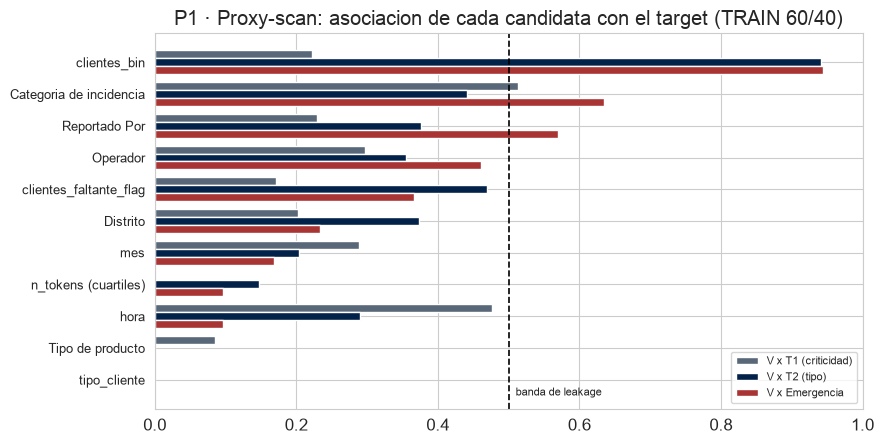

In [6]:
# Figura del proxy-scan: asociacion de cada candidata con cada eje del target (TRAIN).
fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(len(scan))
ax.barh(y - 0.25, scan.V_T1, height=0.25, color=SLATE, label="V x T1 (criticidad)")
ax.barh(y, scan.V_T2, height=0.25, color=NAVY, label="V x T2 (tipo)")
ax.barh(y + 0.25, scan.V_Emerg, height=0.25, color=ROJO, label="V x Emergencia")
ax.set_yticks(y); ax.set_yticklabels(scan.feature, fontsize=9); ax.invert_yaxis()
ax.axvline(0.50, color="black", ls="--", lw=1.2); ax.text(0.51, len(scan) - 0.5, "banda de leakage", fontsize=8)
ax.set_xlim(0, 1.0)
ax.set_title("P1 · Proxy-scan: asociacion de cada candidata con el target (TRAIN 60/40)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**Hallazgo del firewall.** Dos features son casi-copias post-hoc de (medio) target y ambas se
excluyen con el mismo criterio: `Categoria de incidencia` (V x Emergencia ~ 0,63, se refina al
diagnosticar) y `clientes_bin` (V x Emergencia ~ 0,94, casi una identidad con Emergencia; de hecho la
correccion de calidad de un caso del target uso "clientes afectados" como evidencia de gravedad).
Usarlas seria predecir el target con una copia del target. `Operador` y `Reportado Por` se excluyen
por sesgo de identidad. El feature set estructural que sobrevive es deliberadamente magro, y esa es la
apuesta del experimento: si lo estructural no discrimina, el contraste con el texto sera el hallazgo.

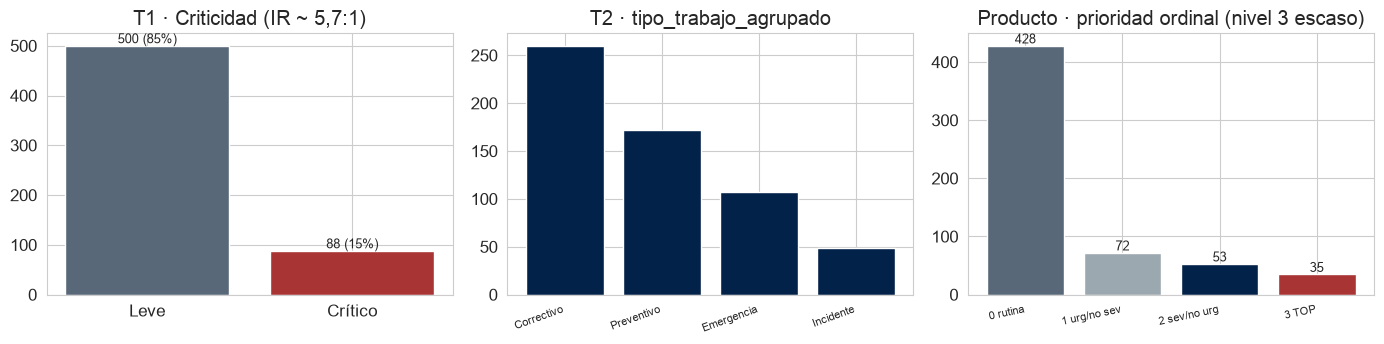

Solo 35 tickets son nivel-3 (Critico y Emergencia) en TODO el dataset:
ese positivo rarisimo es la raiz de la varianza alta y del techo de potencia del ranking.


In [7]:
# Distribucion de los dos targets y del nivel ordinal (lo que de verdad optimiza el producto).
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
_vc1 = df_full["Criticidad"].value_counts()
ax[0].bar(_vc1.index, _vc1.values, color=[SLATE, ROJO])
for i, v in enumerate(_vc1.values):
    ax[0].text(i, v + 5, f"{v} ({v/len(df_full)*100:.0f}%)", ha="center", fontsize=9)
ax[0].set_title("T1 · Criticidad (IR ~ 5,7:1)")
_vc2 = df_full["tipo_trabajo_agrupado"].value_counts()
ax[1].bar(range(len(_vc2)), _vc2.values, color=NAVY)
ax[1].set_xticks(range(len(_vc2))); ax[1].set_xticklabels(_vc2.index, rotation=20, ha="right", fontsize=8)
ax[1].set_title("T2 · tipo_trabajo_agrupado")
_lab = {0: "0 rutina", 1: "1 urg/no sev", 2: "2 sev/no urg", 3: "3 TOP"}
_vc3 = df_full["nivel_ordinal"].value_counts().sort_index()
ax[2].bar([_lab[k] for k in [0, 1, 2, 3]], [int(_vc3.get(k, 0)) for k in [0, 1, 2, 3]],
          color=[SLATE, "#9CA8B0", NAVY, ROJO])
for i, k in enumerate([0, 1, 2, 3]):
    ax[2].text(i, int(_vc3.get(k, 0)) + 4, str(int(_vc3.get(k, 0))), ha="center", fontsize=9)
ax[2].set_xticklabels([_lab[k] for k in [0, 1, 2, 3]], rotation=12, ha="right", fontsize=8)
ax[2].set_title("Producto · prioridad ordinal (nivel 3 escaso)")
plt.tight_layout(); plt.show()
print(f"Solo {int(_vc3.get(3, 0))} tickets son nivel-3 (Critico y Emergencia) en TODO el dataset:")
print("ese positivo rarisimo es la raiz de la varianza alta y del techo de potencia del ranking.")

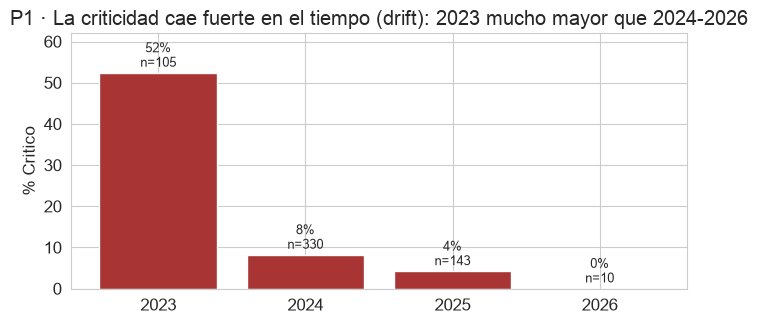

Tasa de Critico por anio (%):
anio
2023    52.4
2024     8.2
2025     4.2
2026     0.0

Consecuencia: cualquier variable atada al calendario quedara espuriamente asociada a la
criticidad, y un split temporal puro EXHIBIRA este drift por diseno (train ~ 22% -> test ~ 5%).


In [8]:
# Deriva temporal de la criticidad: el hecho que condiciona el split y la validacion.
drift = df_full.groupby("anio")["target_criticidad"].agg(["size", "mean"])
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(drift.index.astype(str), drift["mean"] * 100, color=ROJO)
for i, (a, row) in enumerate(drift.iterrows()):
    ax.text(i, row["mean"] * 100 + 1.5, f"{row['mean']*100:.0f}%\nn={int(row['size'])}", ha="center", fontsize=9)
ax.set_ylabel("% Critico"); ax.set_ylim(0, 62)
ax.set_title("P1 · La criticidad cae fuerte en el tiempo (drift): 2023 mucho mayor que 2024-2026")
plt.tight_layout(); plt.show()
print("Tasa de Critico por anio (%):")
print((drift["mean"] * 100).round(1).to_string())
print("\nConsecuencia: cualquier variable atada al calendario quedara espuriamente asociada a la")
print("criticidad, y un split temporal puro EXHIBIRA este drift por diseno (train ~ 22% -> test ~ 5%).")

> **En terminos simples.** Buscamos "soplones" que ya sepan la respuesta y los sacamos: la categoria
> de la incidencia y el flag de clientes afectados delatan casi por completo el tipo de emergencia,
> porque se rellenan despues de saber que paso. Ademas notamos que en 2023 las fallas eran muchas y
> graves y luego se estabilizo: por eso cualquier cosa atada a la fecha *parecera* causa de criticidad
> sin serlo, y por eso el pasado tiene que entrenar y el futuro evaluar.

# P2 · Particion temporal 60/40 con embargo de 7 dias

El modelado necesita un regimen realista: entrenar con el pasado, evaluar con el futuro. Por eso el
split es **temporal puro** (ordenar por fecha, cortar 60/40, sin barajar ni estratificar). Estratificar
mezclaria futuro y pasado, que es justo la fuga que queremos evitar. Un detalle de cimiento: un bug de
parseo de fechas, ya corregido, revolvia el orden temporal; con las fechas correctas el `test` queda
con **11 criticos**.

Ademas, como la etiqueta **madura despues** del t = 0, aplicamos un **embargo**: se purgan del train
los tickets abiertos dentro de los 7 dias previos al corte, para que su criticidad (que se consolida
mas tarde) no se filtre al territorio de test.

In [9]:
# El split con embargo, leido del diagnostico del loader (codigo real exhibido en Utilidades).
print(f"gap del embargo        : {diag['gap_dias']} dias")
print(f"punto de corte (split) : {diag['split_point']}")
print(f"corte del embargo      : {diag['corte_embargo']}")
print(f"train: {diag['n_train'][0]} -> {diag['n_train'][1]}  ({diag['n_train'][0]-diag['n_train'][1]} purgados)")
print(f"criticos train (post)  : {diag['criticos_train'][1]}")
print(f"test (intacto)         : {diag['n_test']} tickets, {diag['criticos_test']} criticos")
print()
print(f"Drift por diseno: train {df_train['target_criticidad'].mean()*100:.1f}% criticos -> "
      f"test {df_test['target_criticidad'].mean()*100:.1f}%  (global {df_full['target_criticidad'].mean()*100:.1f}%).")
print("Suprimir ese drift con estratificacion + barajado SERIA leakage temporal.")

gap del embargo        : 7 dias
punto de corte (split) : 2024-10-10
corte del embargo      : 2024-10-03
train: 352 -> 345  (7 purgados)
criticos train (post)  : 77
test (intacto)         : 236 tickets, 11 criticos

Drift por diseno: train 22.3% criticos -> test 4.7%  (global 15.0%).
Suprimir ese drift con estratificacion + barajado SERIA leakage temporal.


### El firewall del target, demostrado (no afirmado)

Decir "exclui `Categoria de incidencia` y `clientes_bin`" es una afirmacion. Aqui lo **demostramos**:
las prohibidas existen en el dataframe (excluirlas es una decision), un `assert` hace fallar el
notebook si alguna se cuela, y el `ColumnTransformer` con `remainder='drop'` **descarta fisicamente**
todo lo no seleccionado aunque le pasemos el dataframe completo. El modelo como *pipeline entero*
tambien cierra la fuga de preprocesamiento: sus parametros (media del scaler, categorias del distrito)
se aprenden **solo del train**.

In [10]:
# FIREWALL demostrado + no-fuga de preprocesamiento (todo estructural; sin embeddings).
COLS = NUM_COLS + CAT_COLS
TARGET_RAW = ["target_criticidad", "target_t2", "Criticidad", "Tipo de trabajo"]
PROXIES = ["Categoría de incidencia", "clientes_bin"]           # los dos proxies del EDA
PROHIBIDAS = TARGET_RAW + PROXIES

# (1) Las prohibidas EXISTEN -> excluirlas es una decision, no una ausencia accidental.
print("Prohibidas presentes en df_train:",
      [c for c in PROHIBIDAS if c in df_train.columns])

# (2) ASSERT: ninguna prohibida entra al pipeline.
fuga = set(COLS) & set(PROHIBIDAS)
assert not fuga, f"FUGA: prohibidas dentro del pipeline -> {fuga}"
assert "clientes_faltante_flag" in COLS and "clientes_bin" not in COLS
print(f"OK · el pipeline usa {COLS} y ninguna prohibida.")

# (3) ESTRUCTURAL: remainder='drop' descarta lo no seleccionado (causa + efecto).
assert build_preprocessor().remainder == "drop", "remainder != 'drop'"
prep = build_preprocessor().fit(df_train[COLS], y_train)
Z_solo = build_preprocessor().fit_transform(df_train[COLS], y_train)
prep_full = build_preprocessor().fit(df_train, y_train)
Z_todo = prep_full.transform(df_train)
cols_dentro = [c for nom, tr, cols in prep_full.transformers_ if nom != "remainder" for c in cols]
assert Z_solo.shape[1] == Z_todo.shape[1] and not (set(cols_dentro) & set(PROHIBIDAS))
print(f"OK · frame completo ({df_train.shape[1]} cols) y solo permitidas ({len(COLS)}) -> "
      f"MISMO nro de features: {Z_solo.shape[1]}. El target no puede entrar aunque uno se descuide.")

# El scaler aprende SOLO de train (no re-aprende sobre test):
print(f"\nStandardScaler.mean_ (aprendido de train): {prep.named_transformers_['num'].mean_.round(3)}")
print(f"media de esas columnas en TEST (NO usada) : {df_test[NUM_COLS].astype(float).mean().values.round(3)}")

Prohibidas presentes en df_train: ['target_criticidad', 'target_t2', 'Criticidad', 'Tipo de trabajo', 'Categoría de incidencia', 'clientes_bin']
OK · el pipeline usa ['n_tokens', 'clientes_faltante_flag', 'Distrito'] y ninguna prohibida.
OK · frame completo (29 cols) y solo permitidas (3) -> MISMO nro de features: 15. El target no puede entrar aunque uno se descuide.

StandardScaler.mean_ (aprendido de train): [10.82   0.693]
media de esas columnas en TEST (NO usada) : [7.03  0.326]


> **En terminos simples.** Partimos los tickets por fecha: el 60% mas antiguo para aprender, el 40%
> mas nuevo para evaluar, como pasaria en produccion. No equilibramos las clases a proposito porque eso
> mezclaria futuro y pasado. Y no te pedimos que confies en que quitamos las columnas trampa: el modelo
> esta construido para tomar solo tres (longitud del texto, una bandera y el distrito) y tirar el resto,
> aunque se las pasemos todas. Si alguna prohibida lograra entrar, el cuaderno se detiene con un error.

# P3 · La escalera de representacion (T1 y T2)

Comparamos de simple a complejo, ordenando por cuanta estructura del lenguaje usa cada peldano. La
metrica de T1 es **AUC-PR** (no accuracy: con 4,7% de criticos, predecir "todo leve" da 95% de
accuracy y cero utilidad). Su **piso de no-skill es la prevalencia**; un modelo "supera el piso" solo
si su Delta contra el piso tiene un IC95 que **no incluye 0**.

- **N0 · piso** (sin senal): la prevalencia (0,047).
- **N1 · estructural** (Random Forest sobre distrito + longitud + bandera): el control que esperamos que falle.
- **N2 · lexico** (TF-IDF + regresion logistica): el texto como bolsa de palabras.
- **N3 · semantico** (embeddings BETO / e5 / MiniLM + regresion logistica): el texto como significado.

In [11]:
# Escalera T1: AUC-PR con IC95 y Delta vs piso (leida del artefacto canonico).
orden_t1 = ["rf_estructural", "tfidf_lr", "emb_minilm_multilingual_lr",
            "emb_e5_multilingual_lr", "emb_beto_meanpool_lr"]
filas = []
for k in orden_t1:
    r = ESC["escalera"][k]
    filas.append({
        "nivel": r["modelo"],
        "AUC-PR": round(r["auc_pr"], 3),
        "IC95 AUC-PR": f"[{r['auc_pr_ic95'][0]:.3f}, {r['auc_pr_ic95'][1]:.3f}]",
        "Delta vs piso (IC95)": f"[{r['delta_vs_piso_ic95'][0]:+.3f}, {r['delta_vs_piso_ic95'][1]:+.3f}]",
        "supera piso": "SI" if r["delta_ic_excluye_0_por_arriba"] else "NO (IC incluye 0)",
    })
print(f"piso de no-skill (prevalencia) = {piso:.3f}")
print(pd.DataFrame(filas).to_string(index=False))

piso de no-skill (prevalencia) = 0.047
                      nivel  AUC-PR    IC95 AUC-PR Delta vs piso (IC95)       supera piso
          N1 RF estructural   0.071 [0.022, 0.277]     [-0.011, +0.231] NO (IC incluye 0)
             N2 TF-IDF + LR   0.166 [0.058, 0.428]     [+0.024, +0.376]                SI
N3 minilm_multilingual + LR   0.196 [0.049, 0.476]     [+0.017, +0.430]                SI
    N3 e5_multilingual + LR   0.251 [0.076, 0.514]     [+0.041, +0.467]                SI
      N3 beto_meanpool + LR   0.427 [0.158, 0.739]     [+0.124, +0.696]                SI


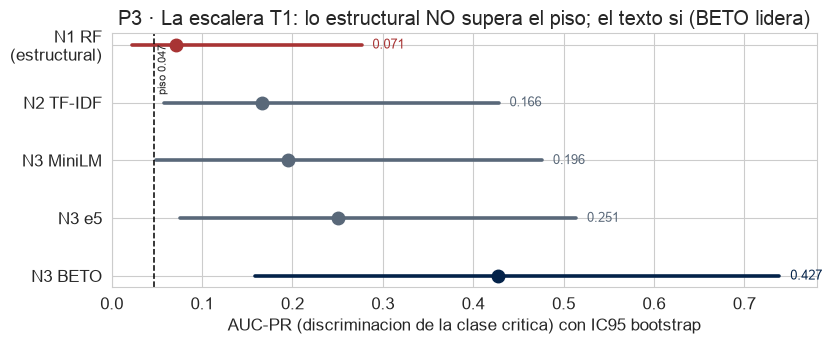

In [12]:
# Figura: forest plot de la escalera T1 (AUC-PR con IC95 y el piso de no-skill).
fig, ax = plt.subplots(figsize=(8.5, 3.6))
etq = {"rf_estructural": "N1 RF\n(estructural)", "tfidf_lr": "N2 TF-IDF",
       "emb_minilm_multilingual_lr": "N3 MiniLM", "emb_e5_multilingual_lr": "N3 e5",
       "emb_beto_meanpool_lr": "N3 BETO"}
ys = np.arange(len(orden_t1))[::-1]
for y_, k in zip(ys, orden_t1):
    r = ESC["escalera"][k]; lo, hi = r["auc_pr_ic95"]
    col = ROJO if k == "rf_estructural" else (NAVY if k == "emb_beto_meanpool_lr" else SLATE)
    ax.plot([lo, hi], [y_, y_], color=col, lw=2.6, solid_capstyle="round")
    ax.plot(r["auc_pr"], y_, "o", color=col, ms=9)
    ax.text(hi + 0.012, y_, f"{r['auc_pr']:.3f}", va="center", fontsize=9, color=col)
ax.axvline(piso, color="black", ls="--", lw=1.1)
ax.text(piso + 0.004, len(orden_t1) - 1.0, f"piso {piso:.3f}", fontsize=8, rotation=90, va="top")
ax.set_yticks(ys); ax.set_yticklabels([etq[k] for k in orden_t1])
ax.set_xlabel("AUC-PR (discriminacion de la clase critica) con IC95 bootstrap")
ax.set_title("P3 · La escalera T1: lo estructural NO supera el piso; el texto si (BETO lidera)")
ax.set_xlim(0, 0.78); plt.tight_layout(); plt.show()

**Lectura de la escalera T1.** El Random Forest estructural da **AUC-PR 0,071**, con Delta vs
piso cuyo IC95 **incluye 0**: no supera el azar de forma robusta. No es un tropiezo, es un resultado,
confirma que ninguna senal estructural en t = 0 discrimina la criticidad, y ese negativo es lo que
vuelve *significativo* que el texto si lo haga. El TF-IDF sube a **0,166** (ya cruza el piso), y los
embeddings escalan a **0,196 (MiniLM), 0,251 (e5) y 0,427 (BETO)**: a mas capacidad semantica, mas
senal. Dentro de la familia semantica los IC95 se solapan, asi que la afirmacion honesta es "la
familia semantica supera el piso", no "BETO es mejor que e5"; se despliega **BETO** por mejor punto y
por estar preentrenado en espanol (el dominio del NOC), una decision de ingenieria.

In [13]:
# Escalera T2 (urgencia): la misma pregunta, ahora sobre el tipo de trabajo. Metrica: F1 macro.
orden_t2 = [("n0_dummy", "N0 Dummy"), ("n1_estructural_tuneado", "N1 estructural (tuneado)"),
            ("n2_tfidf_lr", "N2 TF-IDF"), ("n3_emb_beto_meanpool_lr", "N3 BETO"),
            ("n3_emb_e5_multilingual_lr", "N3 e5"), ("n3_emb_minilm_multilingual_lr", "N3 MiniLM")]
print(f"{'Nivel T2':<28}{'F1 macro':>9}{'IC95':>18}{'Emerg P/R/F1':>18}")
for k, nom in orden_t2:
    r = ESC_T2["niveles"][k]; ic = r["f1_macro_ic95"]; e = r["emergencia"]
    print(f"{nom:<28}{r['f1_macro']:>9.3f}  [{ic[0]:.3f},{ic[1]:.3f}]  {e['precision']:.2f}/{e['recall']:.2f}/{e['f1']:.2f}")
print()
print("El estructural se queda ~0,25; el texto sube a ~0,40-0,46, con el IC del estructural sin solaparse.")
print("Anti-circular T2: la precision de Emergencia del texto ~0,26 (lejos de 1,0) -> el texto NO copia la etiqueta.")

Nivel T2                     F1 macro              IC95      Emerg P/R/F1
N0 Dummy                        0.131  [0.113,0.147]  0.00/0.00/0.00
N1 estructural (tuneado)        0.254  [0.200,0.310]  0.12/0.57/0.20
N2 TF-IDF                       0.464  [0.420,0.506]  0.26/0.83/0.39
N3 BETO                         0.428  [0.384,0.471]  0.26/0.77/0.39
N3 e5                           0.439  [0.395,0.480]  0.25/0.83/0.38
N3 MiniLM                       0.402  [0.354,0.449]  0.23/0.73/0.35

El estructural se queda ~0,25; el texto sube a ~0,40-0,46, con el IC del estructural sin solaparse.
Anti-circular T2: la precision de Emergencia del texto ~0,26 (lejos de 1,0) -> el texto NO copia la etiqueta.


> **En terminos simples.** Probamos varios niveles, del mas simple al mas sofisticado, para las dos
> preguntas (que tan grave y que tan urgente). En ambas, los datos estructurados apenas le ganan al
> azar, pero apenas el modelo mira las palabras de la descripcion empieza a acertar, y cuanto mejor
> entiende el idioma, mejor distingue. La pista vive en lo que dice el ticket, no en sus metadatos.

# P4 · Validez de la senal: ¿por que creerle a este 0,427?

Un numero alto y favorable **deberia dar desconfianza, no euforia**. Sometemos el AUC-PR de BETO a la
misma desconfianza que elimino a los proxies del firewall, con cuatro verificaciones: procedencia
(la etiqueta se derivo de la magnitud medida, no del texto), prueba de permutacion, chequeo
anti-circular por comportamiento del modelo, y analisis de terminos.

AUC-PR real (BETO)                 = 0.4275
AUC-PR nulas (200 barajados)       : media=0.0888  max=0.4209
Barajados que alcanzan al real     = 0 de 200
p-valor p = (k_alcanzan + 1) / (n_permutaciones + 1)            = 0.005


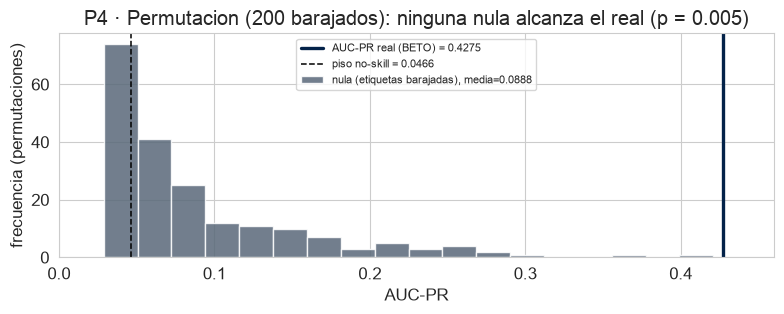

In [14]:
# (a) Prueba de permutacion: re-entrenar la misma cabeza con etiquetas barajadas 200 veces.
P = VAL["permutacion"]
print(f"AUC-PR real (BETO)                 = {P['aucpr_real']}")
print(f"AUC-PR nulas (200 barajados)       : media={P['media_nulas']}  max={P['max_nulas']}")
print(f"Barajados que alcanzan al real     = {P['k_alcanzan_real']} de {P['n_permutaciones']}")
print(f"p-valor {P['p_formula']}            = {P['p_valor']}")

fig, ax = plt.subplots(figsize=(8, 3.3))
bordes = P["hist_bordes"]; frec = P["hist_frecuencias"]
ax.bar(bordes[:-1], frec, width=np.diff(bordes), align="edge", color=SLATE, alpha=0.85,
       edgecolor="white", label=f"nula (etiquetas barajadas), media={P['media_nulas']}")
ax.axvline(P["aucpr_real"], color=NAVY, lw=2.4, label=f"AUC-PR real (BETO) = {P['aucpr_real']}")
ax.axvline(piso, color="black", ls="--", lw=1.1, label=f"piso no-skill = {piso}")
ax.set_xlabel("AUC-PR"); ax.set_ylabel("frecuencia (permutaciones)")
ax.set_title(f"P4 · Permutacion ({P['n_permutaciones']} barajados): ninguna nula alcanza el real (p = {P['p_valor']})")
ax.legend(fontsize=8, loc="upper center"); ax.set_xlim(0, max(0.46, P["aucpr_real"] + 0.03))
plt.tight_layout(); plt.show()

In [15]:
# (b) Anti-circularidad: si el modelo leyera la respuesta, sus apuestas mas seguras serian
# casi todas criticas. (c) Terminos: las palabras predictoras deberian ser fisicas de t=0, no de cierre.
AC = VAL["anti_circularidad"]
print("Top-K por confianza del modelo (¿acierta 'casi perfecto' como un modelo circular?):")
for k, r in AC["topk_confianza"].items():
    print(f"  {k:>6}: {r['criticos_reales']}/{r['K']} criticos reales (precision {r['precision']})")
print("  -> entre los 11 de maxima confianza, 5/11 son criticos (~45%): predice con incertidumbre real,")
print("     no memoriza. Un modelo que leyera la respuesta acertaria casi 100%.")
print()
print("Terminos que MAS empujan a CRITICO (coeficientes TF-IDF + LR):")
print("  ", AC["terminos_criticos_top12"])
print("Terminos que MAS empujan a LEVE:")
print("  ", AC["terminos_leves_top8"])
print("  -> vocabulario FISICO de apertura (corte, rotura, fibra); las palabras de cierre empujan a LEVE.")

Top-K por confianza del modelo (¿acierta 'casi perfecto' como un modelo circular?):
   top_5: 3/5 criticos reales (precision 0.6)
   top_8: 4/8 criticos reales (precision 0.5)
  top_11: 5/11 criticos reales (precision 0.455)
  -> entre los 11 de maxima confianza, 5/11 son criticos (~45%): predice con incertidumbre real,
     no memoriza. Un modelo que leyera la respuesta acertaria casi 100%.

Terminos que MAS empujan a CRITICO (coeficientes TF-IDF + LR):
   ['corte de', 'corte', 'estado', 'de address', 'servicio vertical', 'de', 'cto sin', 'rotura de', 'cto', 'fibra optica', 'en mal', 'mal estado']
Terminos que MAS empujan a LEVE:
   ['auditoria', 'normalizacion', 'auditoria en', 'troncal_te789ab9840', 'el', 'address address', 'en dist_001', 'grupo electrogeno']
  -> vocabulario FISICO de apertura (corte, rotura, fibra); las palabras de cierre empujan a LEVE.


> **En terminos simples.** Barajamos las respuestas 200 veces y volvimos a entrenar: ni una sola
> vez el modelo con etiquetas falsas alcanzo al real (probabilidad por azar de 0,5 por ciento, p =
> 0,005). Ademas, cuando le pedimos sus 11 casos mas sospechosos, acierta 5 (uno de cada dos, no hace
> trampa), y las palabras que lo activan son las del problema fisico al abrir el ticket, no las del
> cierre. La senal es genuina.

# P5 · El producto operativo full-semantico (resultado definitivo)

El NOC no prioriza por criticidad sola: combina **severidad** (T1) y **urgencia** (T2) en una matriz
ordinal de 4 niveles, y ordena por el score combinado (`nivel + 0,1·P(critico)`) en ventanas de 7
dias con capacidad K = 5. Como ambos ejes viven en el texto de t = 0, la eleccion coherente es
alimentar el ranking con **ambos leidos del texto**.

El sistema **full-semantico** (T1 = BETO x T2 = BETO) alcanza **NDCG@5 = 0,8736** y **Recall@5 de
nivel-3 = 1,0**: captura los cinco eventos de maxima prioridad, distribuidos en tres ventanas, sin
perder ninguno. Es robusto frente al codificador de texto (TF-IDF, BETO y e5 rinden entre 0,87 y 0,90
con recall 1,0). Como **ablacion de una linea**, sustituir el segundo eje por un clasificador de
urgencia **estructural** rebaja el producto a NDCG 0,659 y recall 0,833: la ganancia viene del
tratamiento semantico de la urgencia, no de un artefacto del ranking.

In [16]:
# El producto reportado, su ablacion y el checkpoint que AISLA T1 (leidos del artefacto canonico).
ck = PRODSEM["checkpoint_beto_vs_dummy_con_t2beto"]
assert ck["recall_beto"] == 1.0 and abs(ck["ndcg_beto"] - 0.8736) < 1e-4, "el producto reportado debe ser el full-semantico"

print("PRODUCTO REPORTADO (full-semantico, T1=BETO x T2=BETO), ventanas 7d, K=5:")
print(f"  NDCG@5 = {ck['ndcg_beto']:.4f}   Recall@5 nivel-3 = {ck['recall_beto']:.4f}   "
      f"({ERR['full_semantico']['criticos_en_top5']}/{ERR['full_semantico']['criticos_t1_total']} criticos en Top-5, "
      f"{ERR['resumen_narrativo']['n_fn_ranking_semantico']} FN de ranking)")
print()
print("Robustez frente al codificador de T2 (T1=BETO fijo):")
print(f"  {'T2 usado':<24}{'NDCG@5':>9}{'Recall@5 niv3':>15}")
for clave, etq2 in [("beto", "BETO (reportado)"), ("tfidf", "TF-IDF"), ("e5", "e5"),
                    ("estructural", "estructural (ablacion)")]:
    r = PRODSEM["comparacion_por_t2"][clave]
    print(f"  {etq2:<24}{r['ndcg_beto']:>9.4f}{r['recall_beto']:>15.4f}")

PRODUCTO REPORTADO (full-semantico, T1=BETO x T2=BETO), ventanas 7d, K=5:
  NDCG@5 = 0.8736   Recall@5 nivel-3 = 1.0000   (11/11 criticos en Top-5, 0 FN de ranking)

Robustez frente al codificador de T2 (T1=BETO fijo):
  T2 usado                   NDCG@5  Recall@5 niv3
  BETO (reportado)           0.8736         1.0000
  TF-IDF                     0.8951         1.0000
  e5                         0.8931         1.0000
  estructural (ablacion)     0.6585         0.8333


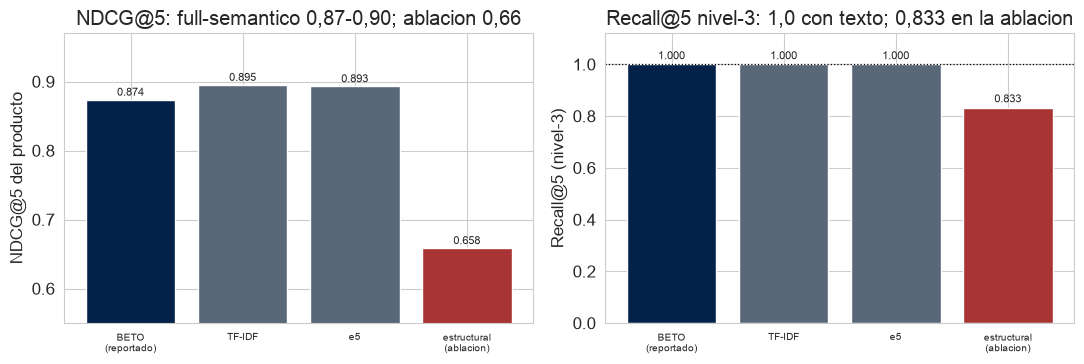

In [17]:
# Figura: el producto es robusto al codificador de T2; la ablacion estructural, por debajo.
t2_keys = ["beto", "tfidf", "e5", "estructural"]
t2_lbl = ["BETO\n(reportado)", "TF-IDF", "e5", "estructural\n(ablacion)"]
ndcg_v = [PRODSEM["comparacion_por_t2"][k]["ndcg_beto"] for k in t2_keys]
rec_v = [PRODSEM["comparacion_por_t2"][k]["recall_beto"] for k in t2_keys]
cols = [NAVY, SLATE, SLATE, ROJO]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.bar(t2_lbl, ndcg_v, color=cols)
for i, v in enumerate(ndcg_v):
    a1.text(i, v + 0.006, f"{v:.3f}", ha="center", fontsize=8)
a1.set_ylim(0.55, 0.97); a1.set_ylabel("NDCG@5 del producto")
a1.set_title("NDCG@5: full-semantico 0,87-0,90; ablacion 0,66"); a1.tick_params(axis="x", labelsize=7)
a2.bar(t2_lbl, rec_v, color=cols); a2.axhline(1.0, color="black", ls=":", lw=0.9)
for i, v in enumerate(rec_v):
    a2.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)
a2.set_ylim(0, 1.12); a2.set_ylabel("Recall@5 (nivel-3)")
a2.set_title("Recall@5 nivel-3: 1,0 con texto; 0,833 en la ablacion"); a2.tick_params(axis="x", labelsize=7)
plt.tight_layout(); plt.show()

In [18]:
# Analisis de errores del ranking + la honestidad del Delta que AISLA T1.
C = ERR["full_semantico"]["contabilidad"]; Cest = ERR["estructural_referencia"]["contabilidad"]
print(f"Tickets nivel-3 en test          : {C['tickets_nivel3_en_test']}")
print(f"Ventanas (7d) con nivel-3        : {C['ventanas_con_nivel3']}")
print(f"Recall por ventana (full-sem)    : {C['recalls_por_ventana']}  -> agregado {C['recall_agregado_promedio']:.3f}")
print(f"Recall por ventana (ablacion est): {Cest['recalls_por_ventana']}  -> agregado {Cest['recall_agregado_promedio']:.3f}")
print(f"Criticos en Top-5 de su ventana  : full-semantico {ERR['full_semantico']['criticos_en_top5']}/11  "
      f"vs ablacion estructural {ERR['estructural_referencia']['criticos_en_top5']}/11")
print()
print("Checkpoint que AISLA la contribucion de T1 (BETO-T1 vs azar-T1, con T2=BETO comun a ambos brazos):")
print(f"  Delta-NDCG = {ck['delta_mean']:+.4f}  IC95 = [{ck['delta_ic95'][0]:+.4f}, {ck['delta_ic95'][1]:+.4f}]  "
      f"(incluye 0: {not ck['delta_ic_excluye_0']})  p = {ck['p_unilateral_beto_mejor']:.4f}")
print("  INVARIANTE: el desempeno ABSOLUTO sube (recall 0,833->1,0; NDCG 0,659->0,874) PERO el Delta que")
print("  aisla T1 SIGUE incluyendo 0. T2 es comun a ambos brazos: mejorarlo sube el sistema y el baseline")
print("  por igual, asi que la diferencia no cambia. El limite es MUESTRAL (11 criticos), no del modelo.")

Tickets nivel-3 en test          : 5
Ventanas (7d) con nivel-3        : 3
Recall por ventana (full-sem)    : [1.0, 1.0, 1.0]  -> agregado 1.000
Recall por ventana (ablacion est): [0.5, 1.0, 1.0]  -> agregado 0.833
Criticos en Top-5 de su ventana  : full-semantico 11/11  vs ablacion estructural 8/11

Checkpoint que AISLA la contribucion de T1 (BETO-T1 vs azar-T1, con T2=BETO comun a ambos brazos):
  Delta-NDCG = +0.0872  IC95 = [-0.0153, +0.1918]  (incluye 0: True)  p = 0.0545
  INVARIANTE: el desempeno ABSOLUTO sube (recall 0,833->1,0; NDCG 0,659->0,874) PERO el Delta que
  aisla T1 SIGUE incluyendo 0. T2 es comun a ambos brazos: mejorarlo sube el sistema y el baseline
  por igual, asi que la diferencia no cambia. El limite es MUESTRAL (11 criticos), no del modelo.


**El matiz honesto (invariante).** El desempeno absoluto del producto es alto, pero la
contribucion **marginal** de T1, aislada comparando el sistema contra una linea base que ordena la
severidad al azar con el mismo segundo eje, no alcanza significancia: **Delta-NDCG = +0,087, IC95
[−0,015, +0,192], p = 0,055**, el intervalo sigue incluyendo 0. La razon es muestral: con solo 11
criticos el margen para demostrar esa contribucion marginal es estrecho. **El desempeno sube; la
significancia marginal de T1, no.** El claim que se sostiene es el signo robusto ("la semantica de la
descripcion en t = 0 anticipa la criticidad mejor que el azar") junto con el producto definitivo
(recall 1,0); lo que no se sobrevende es la significancia marginal del eje de severidad.

Delta-NDCG observado     = +0.0872
SE actual (bootstrap)    = 0.0528   con 11 criticos
SE objetivo (poder 80%)  = 0.0311
Criticos necesarios      ~ 32  (2.9x los actuales)
Formula: n_req = n_actual * (SE_actual / SE_objetivo)^2 ; SE_objetivo = |Δ| / (z_0.975 + z_0.80)
Supuestos declarados: ['efecto real = Δ observado', 'SE ∝ 1/sqrt(N críticos)', 'α=0,05 bilateral', 'potencia 0,80']


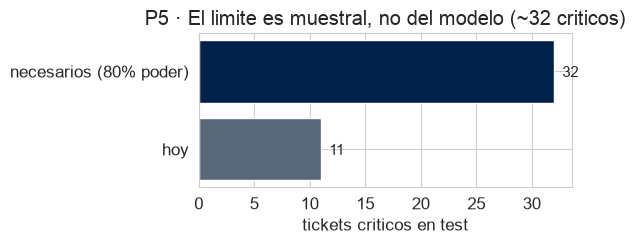

In [19]:
# Potencia (sintetico DECLARADO; no inyecta casos al dataset): cuantos criticos faltan.
PT = ERR["potencia"]
print(f"Delta-NDCG observado     = {PT['delta_ndcg_observado']:+.4f}")
print(f"SE actual (bootstrap)    = {PT['se_actual']}   con {PT['n_criticos_actual']} criticos")
print(f"SE objetivo (poder 80%)  = {PT['se_objetivo_80pct']}")
print(f"Criticos necesarios      ~ {PT['n_criticos_requerido']}  ({PT['factor']}x los actuales)")
print(f"Formula: {PT['formula']}")
print(f"Supuestos declarados: {PT['supuestos']}")

fig, ax = plt.subplots(figsize=(6, 2.6))
ax.barh(["hoy", "necesarios (80% poder)"], [PT["n_criticos_actual"], PT["n_criticos_requerido"]], color=[SLATE, NAVY])
for i, v in enumerate([PT["n_criticos_actual"], PT["n_criticos_requerido"]]):
    ax.annotate(str(v), (v, i), textcoords="offset points", xytext=(6, -4), fontsize=11)
ax.set_xlabel("tickets criticos en test"); ax.set_title("P5 · El limite es muestral, no del modelo (~32 criticos)")
plt.tight_layout(); plt.show()

> **En terminos simples.** Cuando ademas de la severidad leemos la urgencia del mismo texto, la
> lista de prioridades atrapa todos los casos de maxima prioridad de la prueba (cinco de cinco, recall
> 1,0), sin importar que modelo de lenguaje usemos. Ese es el producto que reporta el proyecto. El
> detalle honesto: esa mejora es grande en lo absoluto, pero no cambia la significancia de la parte que
> aporta especificamente el detector de severidad, porque con solo 11 criticos el margen es estrecho.
> Para volverlo demostrable no haria falta un modelo mejor, sino del orden de **~32 criticos** (unas
> 2,9 veces los actuales), que es justo lo que recolectaria un piloto operativo.

# P6 · Calibracion y drift de insumos

Ordenar bien (ranking) no es lo mismo que **cotizar probabilidades fiables**. Medimos la calibracion
del mejor discriminador (BETO) antes y despues de ajustarla, y revisamos si los **insumos** del modelo
cambian de distribucion entre train y test (mas alla del drift intencional del target).

variante         ECE    Brier      BSS
raw            0.319   0.1581  -2.5578
isotonica      0.117   0.0564  -0.2692
platt          0.117   0.0540  -0.2152
Brier de referencia (no-skill) = 0.0444

La isotonica mejora fuerte el ECE (0,319 -> 0,118), pero el BSS sigue negativo (BETO = -0,269):
el modelo ORDENA bien pero NO cotiza probabilidades fiables a este tamano muestral.
Uso legitimo: triaje y ranking, no umbrales de probabilidad exacta.


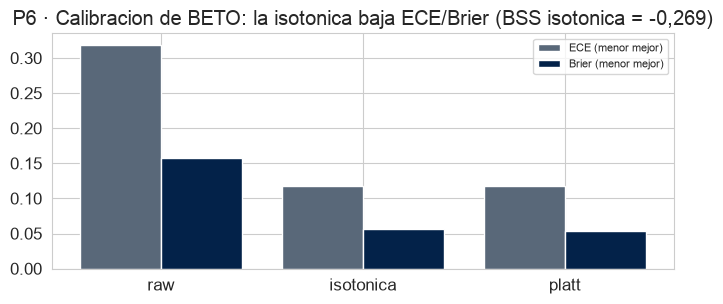

In [20]:
# Calibracion de BETO: ECE / Brier / BSS crudo vs isotonica vs Platt (leido de la escalera canonica).
cal = ESC["escalera"]["emb_beto_meanpool_lr"]["calibracion"]
print(f"{'variante':<12}{'ECE':>8}{'Brier':>9}{'BSS':>9}")
for v in ["raw", "isotonica", "platt"]:
    c = cal[v]
    print(f"{v:<12}{c['ece']:>8.3f}{c['brier']:>9.4f}{c['bss']:>+9.4f}")
print(f"Brier de referencia (no-skill) = {cal['brier_ref_no_skill']}")
print()
print("La isotonica mejora fuerte el ECE (0,319 -> 0,118), pero el BSS sigue negativo (BETO = -0,269):")
print("el modelo ORDENA bien pero NO cotiza probabilidades fiables a este tamano muestral.")
print("Uso legitimo: triaje y ranking, no umbrales de probabilidad exacta.")

fig, ax = plt.subplots(figsize=(7, 3.2))
vs = ["raw", "isotonica", "platt"]
ax.bar(np.arange(3) - 0.2, [cal[v]["ece"] for v in vs], width=0.4, color=SLATE, label="ECE (menor mejor)")
ax.bar(np.arange(3) + 0.2, [cal[v]["brier"] for v in vs], width=0.4, color=NAVY, label="Brier (menor mejor)")
ax.set_xticks(range(3)); ax.set_xticklabels(vs)
ax.set_title("P6 · Calibracion de BETO: la isotonica baja ECE/Brier (BSS isotonica = -0,269)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [21]:
# Drift de insumos train->test (PSI) frente al drift INTENCIONAL del target.
D = VAL["drift"]
print("Drift de INSUMOS (PSI; <0,10 estable · 0,10-0,25 moderado · >0,25 fuerte):")
print(f"  n_tokens : PSI = {D['psi_n_tokens']}")
print(f"  Distrito : PSI = {D['psi_distrito']}")
print(f"Prevalencia del target: train {D['prevalencia_train']:.3f} -> test {D['prevalencia_test']:.3f}")
print(f"Lectura: {D['lectura']}")
print()
print("Los insumos SI driftan algo (PSI 0,69 / 0,89), coherente con un despliegue temporal real; lo")
print("importante es que la caida de prevalencia critica es el fenomeno intencional del split, no un bug.")

Drift de INSUMOS (PSI; <0,10 estable · 0,10-0,25 moderado · >0,25 fuerte):
  n_tokens : PSI = 0.6944
  Distrito : PSI = 0.89
Prevalencia del target: train 0.223 -> test 0.047
Lectura: el drift del target (22,3% -> 4,7%) es INTENCIONAL del split temporal (deck S18); el PSI mide si además driftan los INSUMOS del modelo

Los insumos SI driftan algo (PSI 0,69 / 0,89), coherente con un despliegue temporal real; lo
importante es que la caida de prevalencia critica es el fenomeno intencional del split, no un bug.


> **En terminos simples.** El modelo es bueno **ordenando** la cola (por eso el recall es 1,0),
> pero no hay que leer sus probabilidades como si fueran exactas: aun despues de calibrarlas, su
> "puntaje de calibracion" (BSS = −0,269) sigue por debajo del de referencia, algo esperable con tan
> pocos casos. Y los datos de entrada cambian algo entre entrenamiento y prueba (es un despliegue en
> el tiempo), pero lo que de verdad cambia es cuantos criticos hay, que es el fenomeno real, no un
> defecto.

# P7 · Prototipo de dos capas y reproducibilidad

El hallazgo se materializa en un asistente de **dos capas** para el operador del NOC:

- **Capa 1 · triaje y ranking (deterministica, validada).** Lee la descripcion en t = 0, produce la
  severidad (T1 = BETO) y la urgencia (T2 = BETO), calcula el nivel ordinal y el score combinado, y
  ordena la cola. Reproduce exactamente el producto full-semantico de P5 (los modelos persistidos
  pasan gates de paridad contra el canon).
- **Capa 2 · sugerencias (generativa, prototipo).** A partir del ticket, un modelo de lenguaje local
  propone un runbook de diagnostico y mitigacion en dos etapas. Es un **prototipo demostrado, no un
  resultado validado**: el dataset no tiene ground truth de mitigacion, el operador decide siempre
  (human-in-the-loop) y su evaluacion formal queda como trabajo futuro declarado.

Todo texto que la app muestra pasa por la capa de **pseudonimizacion de PII** (`sanitizar_texto`,
exhibida en Utilidades): la afirmacion de proteccion de datos se respalda con codigo, no solo con
prosa. Y la reproducibilidad se ancla con **integridad criptografica**: cada artefacto canonico tiene
su SHA256 registrado, y el cuaderno lo **verifica** al final (autochequeo).

In [22]:
# Demostracion de la capa de PII (codigo real exhibido en Utilidades) sobre un texto con datos sensibles.
demo = "cliente <CLIENT_042> reporta corte de fibra, IP 10.20.30.40, ticket TCK_A9F3K2, clave=abc123"
limpio, mapeo = sanitizar_texto(demo)
print("PII in :", demo)
print("PII out:", limpio)
print("(las credenciales se REDACTAN; IP / cliente / nodo / ticket se tokenizan con mapeo cifrable)")

PII in : cliente <CLIENT_042> reporta corte de fibra, IP 10.20.30.40, ticket TCK_A9F3K2, clave=abc123
PII out: cliente <CLIENTE_CORP_1> reporta corte de fibra, IP <IP_CRITICA_1>, ticket <TICKET_1>, <CREDENCIAL>
(las credenciales se REDACTAN; IP / cliente / nodo / ticket se tokenizan con mapeo cifrable)


In [23]:
# Latencia bajo carga (artefacto medido): el modelo de texto NO cuesta latencia en este despliegue.
print(f"Piso operativo del NOC: {TORM['limite_p99_noc_ms']:.0f} ms por ticket")
for nombre, r in TORM["resultados"].items():
    print(f"  {nombre:<22} p50={r['p50']:.1f} ms   p99={r['p99']:.1f} ms")
print("-> el modelo responde en decenas de ms por ticket, dos ordenes por debajo del piso de 2s.")

Piso operativo del NOC: 2000 ms por ticket
  N0 · Reglas            p50=0.0 ms   p99=0.0 ms
  N1 · Random Forest     p50=2.1 ms   p99=2.4 ms
  N2 · MiniLM+LR         p50=7.8 ms   p99=35.8 ms
  N3 · BETO+LR           p50=12.8 ms   p99=21.5 ms
  N3 · e5+LR             p50=12.0 ms   p99=110.9 ms
-> el modelo responde en decenas de ms por ticket, dos ordenes por debajo del piso de 2s.


In [24]:
# AUTOCHEQUEO de reproducibilidad: recomputar SHA256 de los artefactos canonicos y comparar al manifest.
manifest = json.load(open(OUT / "manifest_v3clean.json", encoding="utf-8"))
canon = manifest["CANON_V3CLEAN"]
registrados = {**canon.get("inputs", {}), **canon.get("outputs", {})}
verificados, faltantes, mismatches = 0, [], []
for rel, sha_esperado in registrados.items():
    p = ROOT / rel
    if not p.exists():
        faltantes.append(rel); continue
    if calcular_sha256(str(p)) == sha_esperado:
        verificados += 1
    else:
        mismatches.append(rel)
print(f"Artefactos canonicos con SHA256 registrado : {len(registrados)}")
print(f"  verificados (hash coincide)              : {verificados}")
print(f"  ausentes en este clon                    : {len(faltantes)}")
print(f"  con hash distinto (drift)                : {len(mismatches)}")
assert not mismatches, f"Integridad rota (hash distinto): {mismatches}"
print("\nOK · los artefactos presentes coinciden bit a bit con el manifest: el pipeline es reproducible.")

Artefactos canonicos con SHA256 registrado : 17
  verificados (hash coincide)              : 17
  ausentes en este clon                    : 0
  con hash distinto (drift)                : 0

OK · los artefactos presentes coinciden bit a bit con el manifest: el pipeline es reproducible.


> **En terminos simples.** El resultado se usa en una herramienta con dos partes: una que ordena la
> cola de tickets (probada, es el producto de P5) y otra que sugiere pasos de solucion con un modelo
> de lenguaje local (todavia un prototipo, siempre bajo decision humana). Antes de mostrar cualquier
> texto, borramos los datos personales, y verificamos con una huella criptografica que los archivos
> del proyecto no cambiaron. Cualquiera puede reproducir estos numeros.

# Sintesis y trazabilidad

**El cuaderno en una frase.** La pista para anticipar que ticket es critico no esta en sus metadatos,
esta en lo que dice su descripcion al abrirlo, y eso se demuestra con solidez (AUC-PR 0,427, permutacion
p = 0,005, anti-circularidad 5/11). Cuando ademas leemos la urgencia del mismo texto, el ranking de
prioridades captura **todos** los casos criticos de la prueba (NDCG@5 = 0,8736, Recall@5 de nivel-3 =
1,0). Lo unico que, con solo 11 criticos, no alcanzamos a demostrar con certeza es la contribucion
**marginal** por separado del clasificador de severidad: ese es, a la vez, el resultado y su unico
limite, cuantificado en ~32 criticos.

| Fase | Que se computa aqui | Fuente de verdad |
|---|---|---|
| P1 datos + firewall + EDA | proxy-scan y distribuciones (en vivo) | `data/processed/noc-tickets_clean_v2.*`, `src/eda.py` |
| P2 particion + embargo | split, drift, firewall demostrado (en vivo) | `scripts/_avance_final_common.py`, `afg3_baselines_clasicos.py` |
| P3 escalera T1 / T2 | AUC-PR y F1 macro con IC95 (lectura) | `outputs/afg3_escalera_v3clean.json`, `afg3_escalera_t2.json` |
| P4 validez de la senal | permutacion, anti-circularidad (lectura) | `outputs/afg3_validacion_v3clean.json` |
| P5 producto full-semantico | NDCG, Recall@5, checkpoint, potencia (lectura) | `outputs/afg3_producto_t2semantico.json`, `afg3_errores_potencia_t2semantico.json` |
| P6 calibracion + drift | ECE/Brier/BSS, PSI (lectura) | `outputs/afg3_escalera_v3clean.json`, `afg3_validacion_v3clean.json` |
| P7 prototipo + reproducibilidad | PII, latencia, integridad SHA256 (en vivo) | `outputs/afg3_benchmark_tormenta.json`, `outputs/manifest_v3clean.json` |

Este cuaderno fue generado por `scripts/_construir_pipeline_canonico.py` (idempotente) y se ejecuta
end-to-end con `jupyter nbconvert --execute`. Es un visor: no re-entrena modelos; computa en vivo solo
lo ligero del EDA y lee los numeros del modelado y la validacion de artefactos versionados con su
huella SHA256.